# Experimento em grade: defesas no gradiente

**O que este notebook faz:** treina modelos (MLP, CNN, ViT) em MNIST, Fashion-MNIST e CIFAR-10 com várias defesas aplicadas ao gradiente (`none`, `topk`, `dpsgd`, `randomk`, `qsgd`), mede acurácia e gera análises de reconstrução (ataque estilo TP2).

**Como rodar:** execute as células **em ordem de cima para baixo**. As células finais dependem das variáveis definidas nas anteriores (`RUN_TRAINING_GRID`, `RUN_RECONSTRUCTION_PLOTS`, `df_grid`, `summary`, etc.).


In [1]:
import os
import random
from dataclasses import dataclass
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


In [2]:
# --- Célula 2: hiperparâmetros e flags ---
# Responsável por: grade do experimento (arquiteturas, datasets, defesas, batch),
# limites de épocas/amostras, parâmetros das defesas, pasta de saída e flags RUN_*.
# Ajuste N_REPEATS / GRID_* / RUN_TRAINING_GRID aqui antes de treinar.
# Inicializa df_grid e summary para evitar NameError se você pular o treino.

# -------- Configuração --------
GRID_ARCHS = ["mlp", "cnn", "vit"]
GRID_DATASETS = ["mnist", "fashion-mnist", "cifar10"]
GRID_DEFENSES = ["none", "topk", "dpsgd", "randomk", "qsgd"]
GRID_BATCHES = [1, 32]

N_REPEATS = 30
GRID_EPOCHS = 1
GRID_LR = 1e-3
GRID_LIMIT_TRAIN = 4000
GRID_LIMIT_TEST = 1000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TOPK_KEEP_RATIO = 0.1
RANDOMK_KEEP_RATIO = 0.1
DP_CLIP_NORM = 1.0
DP_NOISE_MULT = 1.0
QSGD_LEVELS = 16

OUTDIR = "./figuras_grid"
os.makedirs(OUTDIR, exist_ok=True)

# Checkpoints dos modelos treinados (obrigatório para reconstrução fiel)
SAVE_TRAINED_CHECKPOINTS = True
CHECKPOINT_DIR = "./checkpoints_grid"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Treino completo da grade (muito longo): desligue para só reconstruções / plots rápidos
RUN_TRAINING_GRID = True
RUN_RECONSTRUCTION_PLOTS = True
RECON_SAMPLE_INDICES = [0, 1, 2]  # usado apenas no plot qualitativo rápido
RECON_USE_STRATIFIED = True
RECON_SAMPLES_PER_CLASS = 3
RECON_LBFGS_ITERS = {"mlp": 500, "cnn": 500, "vit": 150}
RECON_SEED_BASE = 12345
RECON_CHECKPOINT_REPEAT_ID = 0
RECON_CHECKPOINT_BATCH_SIZE = 32
REQUIRE_CHECKPOINT_FOR_RECON = True

# Histórico por época: uma linha por (config da grade × repetição × época)
SAVE_EPOCH_HISTORY = True
EVAL_EACH_EPOCH = True  # avalia no teste ao fim de cada época (mais lento se GRID_EPOCHS for alto)
EPOCH_HISTORY_CSV = "resultados_grid_historico_epocas.csv"

# Estado das execuções (sobrescrito na célula de treino)
df_grid = None
summary = None
df_grid_epochs = None


In [3]:
# --- Célula 3: dados e reprodutibilidade ---
# Responsável por: fixar seeds, transforms/normalização por dataset, DataLoaders
# (treino/teste com limite opcional), acesso ao dataset bruto e seleção de índices
# para figuras de reconstrução estratificada.

def set_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def dataset_info(name):
    name = name.lower()
    if name == "mnist":
        tfm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
        ])
        return tfm, 1, 28, 10
    if name == "fashion-mnist":
        tfm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.2860,), (0.3530,)),
        ])
        return tfm, 1, 28, 10
    if name == "cifar10":
        tfm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
        ])
        return tfm, 3, 32, 10
    raise ValueError(f"Dataset não suportado: {name}")


def get_loaders(dataset_name, batch_size, limit_train=None, limit_test=None):
    tfm, in_ch, img_size, n_classes = dataset_info(dataset_name)
    n = dataset_name.lower()
    if n == "mnist":
        train_set = datasets.MNIST("./data", train=True, download=True, transform=tfm)
        test_set = datasets.MNIST("./data", train=False, download=True, transform=tfm)
    elif n == "fashion-mnist":
        train_set = datasets.FashionMNIST("./data", train=True, download=True, transform=tfm)
        test_set = datasets.FashionMNIST("./data", train=False, download=True, transform=tfm)
    elif n == "cifar10":
        train_set = datasets.CIFAR10("./data", train=True, download=True, transform=tfm)
        test_set = datasets.CIFAR10("./data", train=False, download=True, transform=tfm)
    else:
        raise ValueError(dataset_name)

    if limit_train is not None:
        train_set = Subset(train_set, range(min(limit_train, len(train_set))))
    if limit_test is not None:
        test_set = Subset(test_set, range(min(limit_test, len(test_set))))

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=max(64, batch_size), shuffle=False)
    return train_loader, test_loader, in_ch, img_size, n_classes


def get_raw_dataset(dataset_name, train=False):
    """Dataset com o mesmo normalize do treino (entradas no espaço normalizado)."""
    tfm, _, _, _ = dataset_info(dataset_name)
    n = dataset_name.lower()
    if n == "mnist":
        return datasets.MNIST("./data", train=train, download=True, transform=tfm)
    if n == "fashion-mnist":
        return datasets.FashionMNIST("./data", train=train, download=True, transform=tfm)
    if n == "cifar10":
        return datasets.CIFAR10("./data", train=train, download=True, transform=tfm)
    raise ValueError(dataset_name)


def pick_recon_indices(dataset, samples_per_class=RECON_SAMPLES_PER_CLASS, seed=RECON_SEED_BASE):
    """Seleciona índices estratificados por classe para cobrir variações do dataset."""
    rng = np.random.default_rng(seed)
    targets = None
    if hasattr(dataset, 'targets'):
        targets = dataset.targets
    elif hasattr(dataset, 'labels'):
        targets = dataset.labels
    if targets is None:
        # fallback simples
        return list(range(min(10 * samples_per_class, len(dataset))))

    if isinstance(targets, torch.Tensor):
        y = targets.cpu().numpy()
    else:
        y = np.array(targets)

    indices = []
    for c in sorted(np.unique(y)):
        cls_idx = np.where(y == c)[0]
        if len(cls_idx) == 0:
            continue
        k = min(samples_per_class, len(cls_idx))
        sel = rng.choice(cls_idx, size=k, replace=False)
        indices.extend(sel.tolist())
    return sorted(indices)


In [4]:
# --- Célula 4: modelos ---
# Responsável por: definir MLP, CNN e TinyViT e a fábrica build_model().

# -------- Modelos --------
class MLPNet(nn.Module):
    def __init__(self, in_ch, img_size, n_classes):
        super().__init__()
        d = in_ch * img_size * img_size
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(d, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.net(x)


class CNNNet(nn.Module):
    def __init__(self, in_ch, img_size, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        r = img_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * r * r, 256), nn.ReLU(),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class TinyViT(nn.Module):
    def __init__(self, in_ch, img_size, n_classes, patch=4, dim=128, depth=4, heads=4):
        super().__init__()
        assert img_size % patch == 0
        n_patches = (img_size // patch) ** 2
        self.patch_proj = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + n_patches, dim))
        layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim * 2,
            dropout=0.1, activation="gelu", batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth)
        self.head = nn.Linear(dim, n_classes)

    def forward(self, x):
        b = x.size(0)
        x = self.patch_proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(b, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed[:, :x.size(1)]
        x = self.encoder(x)
        return self.head(x[:, 0])


def build_model(arch, in_ch, img_size, n_classes):
    a = arch.lower()
    if a == "mlp":
        return MLPNet(in_ch, img_size, n_classes)
    if a == "cnn":
        return CNNNet(in_ch, img_size, n_classes)
    if a == "vit":
        return TinyViT(in_ch, img_size, n_classes)
    raise ValueError(arch)


In [5]:
# --- Célula 5: defesas no gradiente e laço de treino ---
# Responsável por: comprimir/perturbar gradientes (top-k, DP-SGD, random-k, QSGD),
# um epoch de treino com defesa, Config, run_experiment, grade com repetições
# e resumo estatístico (média ± dp) em DataFrame.

# -------- Defesas (gradientes) --------
def _flatten_grads(grads):
    vecs, shapes = [], []
    for g in grads:
        if g is None:
            shapes.append(None)
        else:
            shapes.append(g.shape)
            vecs.append(g.reshape(-1))
    if not vecs:
        return None, shapes
    return torch.cat(vecs), shapes


def _unflatten(vec, params, shapes):
    out, ptr = [], 0
    for p, s in zip(params, shapes):
        if s is None:
            out.append(None)
        else:
            n = p.numel()
            out.append(vec[ptr:ptr+n].view_as(p))
            ptr += n
    return out


def defense_topk(grads, keep_ratio=TOPK_KEEP_RATIO):
    flat, shapes = _flatten_grads(grads)
    if flat is None:
        return grads
    n = flat.numel()
    k = max(1, int(n * keep_ratio))
    idx = torch.topk(flat.abs(), k=k).indices
    mask = torch.zeros_like(flat)
    mask[idx] = 1.0
    return _unflatten(flat * mask, grads, shapes)


def defense_randomk(grads, keep_ratio=RANDOMK_KEEP_RATIO):
    flat, shapes = _flatten_grads(grads)
    if flat is None:
        return grads
    n = flat.numel()
    k = max(1, int(n * keep_ratio))
    idx = torch.randperm(n, device=flat.device)[:k]
    mask = torch.zeros_like(flat)
    mask[idx] = 1.0
    return _unflatten(flat * mask, grads, shapes)


def defense_dpsgd(grads, clip_norm=DP_CLIP_NORM, noise_mult=DP_NOISE_MULT):
    flat, shapes = _flatten_grads(grads)
    if flat is None:
        return grads
    norm = torch.norm(flat, p=2)
    scale = min(1.0, clip_norm / (norm + 1e-12))
    clipped = flat * scale
    noisy = clipped + torch.randn_like(clipped) * (noise_mult * clip_norm)
    return _unflatten(noisy, grads, shapes)


def defense_qsgd(grads, levels=QSGD_LEVELS):
    flat, shapes = _flatten_grads(grads)
    if flat is None:
        return grads
    s = torch.norm(flat, p=2)
    if s < 1e-12:
        return grads
    scaled = levels * flat.abs() / (s + 1e-12)
    floor = torch.floor(scaled)
    prob = scaled - floor
    q = floor + (torch.rand_like(prob) < prob).float()
    q = torch.clamp(q, max=levels)
    quantized = torch.sign(flat) * s * q / levels
    return _unflatten(quantized, grads, shapes)


def apply_defense(grads, name):
    d = name.lower()
    if d == "none":
        return grads
    if d == "topk":
        return defense_topk(grads)
    if d == "dpsgd":
        return defense_dpsgd(grads)
    if d == "randomk":
        return defense_randomk(grads)
    if d == "qsgd":
        return defense_qsgd(grads)
    raise ValueError(name)


def apply_defense_to_gradient_tuple(grad_tuple, defense_name, seed=None):
    """Converte tupla de gradientes (como em compute_gradient) aplicando a mesma defesa do treino."""
    if seed is not None:
        set_seeds(seed)
    grads = list(grad_tuple)
    out = apply_defense(grads, defense_name)
    return tuple(out)


def make_checkpoint_path(cfg: "Config", config_idx: int, repeat_id: int, seed: int, out_dir: str = CHECKPOINT_DIR) -> str:
    ds = cfg.dataset.replace("-", "_")
    fname = f"cfg{config_idx:03d}_{cfg.arch}_{ds}_{cfg.defense}_b{cfg.batch_size}_rep{repeat_id:02d}_seed{seed}.pt"
    return os.path.join(out_dir, fname)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / max(1, total)


def train_one_epoch(model, loader, opt, device, defense):
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, total_n = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()

        params = [p for p in model.parameters()]
        grads = [p.grad if p.grad is not None else None for p in params]
        grads = apply_defense(grads, defense)
        for p, g in zip(params, grads):
            p.grad = g

        opt.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / max(1, total_n)


@dataclass
class Config:
    arch: str
    dataset: str
    defense: str
    batch_size: int
    epochs: int = GRID_EPOCHS
    lr: float = GRID_LR


def run_experiment(cfg: Config, device=DEVICE):
    tr, te, in_ch, img_size, n_classes = get_loaders(
        cfg.dataset, cfg.batch_size, GRID_LIMIT_TRAIN, GRID_LIMIT_TEST
    )
    model = build_model(cfg.arch, in_ch, img_size, n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    losses = []
    epoch_history = []
    for epoch_idx in range(cfg.epochs):
        loss = train_one_epoch(model, tr, opt, device, cfg.defense)
        losses.append(loss)
        rec = {"epoch": epoch_idx + 1, "train_loss_epoch": loss}
        if EVAL_EACH_EPOCH:
            rec["test_acc_epoch"] = evaluate(model, te, device)
        epoch_history.append(rec)

    if EVAL_EACH_EPOCH and epoch_history:
        acc = epoch_history[-1]["test_acc_epoch"]
    else:
        acc = evaluate(model, te, device)

    out = {
        "arch": cfg.arch,
        "dataset": cfg.dataset,
        "defense": cfg.defense,
        "batch_size": cfg.batch_size,
        "epochs": cfg.epochs,
        "lr": cfg.lr,
        "train_loss_last": losses[-1],
        "test_acc": acc,
    }
    if SAVE_EPOCH_HISTORY:
        out["_epoch_history"] = epoch_history
    return out, model


def run_grid_with_repeats(n_repeats=N_REPEATS, device=DEVICE):
    cfgs = [Config(a, d, f, b) for a, d, f, b in product(GRID_ARCHS, GRID_DATASETS, GRID_DEFENSES, GRID_BATCHES)]
    rows = []
    epoch_rows = []
    total_runs = len(cfgs) * n_repeats
    run_counter = 0
    print(f"Configurações: {len(cfgs)} × {n_repeats} repetições = {total_runs} execuções.")
    for ci, cfg in enumerate(cfgs):
        for rep in range(n_repeats):
            run_counter += 1
            seed = 42 + ci * n_repeats + rep
            set_seeds(seed)
            print(f"[{run_counter:04d}/{total_runs}] seed={seed} | {cfg.arch} | {cfg.dataset} | {cfg.defense} | b={cfg.batch_size}")
            ckpt_path = None
            try:
                r, model = run_experiment(cfg, device)
                hist = r.pop("_epoch_history", None)
                if SAVE_TRAINED_CHECKPOINTS:
                    ckpt_path = make_checkpoint_path(cfg, ci, rep, seed)
                    torch.save(model.state_dict(), ckpt_path)
                r["repeat_id"] = rep
                r["seed"] = seed
                r["config_idx"] = ci
                r["checkpoint_path"] = ckpt_path
                rows.append(r)
                if hist:
                    base = {
                        "config_idx": ci,
                        "repeat_id": rep,
                        "seed": seed,
                        "arch": r["arch"],
                        "dataset": r["dataset"],
                        "defense": r["defense"],
                        "batch_size": r["batch_size"],
                        "lr": r["lr"],
                    }
                    for eh in hist:
                        epoch_rows.append({**base, **eh})
            except Exception as e:
                rows.append({
                    "arch": cfg.arch,
                    "dataset": cfg.dataset,
                    "defense": cfg.defense,
                    "batch_size": cfg.batch_size,
                    "epochs": cfg.epochs,
                    "lr": cfg.lr,
                    "train_loss_last": None,
                    "test_acc": None,
                    "repeat_id": rep,
                    "seed": seed,
                    "config_idx": ci,
                    "checkpoint_path": ckpt_path,
                    "error": str(e),
                })
                print("  erro:", e)
            finally:
                if "model" in locals():
                    del model
    df_main = pd.DataFrame(rows)
    df_ep = pd.DataFrame(epoch_rows) if epoch_rows else pd.DataFrame()
    return df_main, df_ep


def summarize_runs(df: pd.DataFrame) -> pd.DataFrame:
    g = ["arch", "dataset", "defense", "batch_size"]
    return (
        df.groupby(g, dropna=False)
        .agg(
            test_acc_mean=("test_acc", "mean"),
            test_acc_std=("test_acc", "std"),
            train_loss_mean=("train_loss_last", "mean"),
            train_loss_std=("train_loss_last", "std"),
            n_runs=("test_acc", "count"),
        )
        .reset_index()
        .sort_values(["dataset", "arch", "defense", "batch_size"])
    )


In [6]:
# --- Célula 6: ataque / reconstrução (gradient matching) ---
# Responsável por: calcular gradientes w.r.t. parâmetros, inferir rótulo (iDLG),
# otimizar entrada com LBFGS para casar gradiente defendido e métricas MSE no [0,1].

# ---------- Ataque / reconstrução (TP2) ----------
def compute_gradient(model, x, y):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    for p in model.parameters():
        if p.grad is not None:
            p.grad = None
    loss = loss_fn(model(x), y)
    return torch.autograd.grad(loss, tuple(model.parameters()), create_graph=False)


@torch.no_grad()
def infer_label_from_last_bias_grad(model, original_gradient):
    last_bias_grad = None
    for (name, _), g in zip(model.named_parameters(), original_gradient):
        if name.endswith("bias"):
            last_bias_grad = g.detach().flatten()
    if last_bias_grad is None:
        raise RuntimeError("Gradiente de bias da última camada não encontrado.")
    return int(torch.argmin(last_bias_grad).item())


def reconstruct_image(
    model,
    original_gradient,
    img_shape,
    lr=1.0,
    iters=400,
    device=None,
    seed=42,
):
    """Gradient matching no espaço de entrada normalizado (como no treino)."""
    device = device or DEVICE
    set_seeds(seed)
    model.eval()
    if hasattr(torch.backends, "mha") and hasattr(torch.backends.mha, "set_fastpath_enabled"):
        torch.backends.mha.set_fastpath_enabled(False)
    y_idx = infer_label_from_last_bias_grad(model, original_gradient)
    y_true = torch.tensor([y_idx], dtype=torch.long, device=device)
    c, h, w = img_shape
    # Usar nn.Parameter garante tensor folha para o LBFGS.
    x_hat = nn.Parameter(torch.randn(1, c, h, w, device=device) * 0.25)
    optimizer = optim.LBFGS([x_hat], lr=lr, max_iter=20)
    rounds = max(1, iters // 20)
    loss_fn = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad(set_to_none=True)

        # Evita backend de attention sem suporte a derivada de ordem superior no CPU.
        if hasattr(torch.backends, "cuda") and hasattr(torch.backends.cuda, "sdp_kernel"):
            with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_mem_efficient=False, enable_math=True):
                pred = model(x_hat)
        else:
            pred = model(x_hat)

        ce = loss_fn(pred, y_true)
        syn = torch.autograd.grad(ce, tuple(model.parameters()), create_graph=True)
        diff = 0.0
        for sg, og in zip(syn, original_gradient):
            diff = diff + ((sg - og) ** 2).sum()
        diff.backward()
        return diff

    for _ in range(rounds):
        optimizer.step(closure)
        with torch.no_grad():
            x_hat.clamp_(-4.0, 4.0)
    return x_hat.detach(), y_idx


def denormalize_for_display(t, dataset_name):
    """tensor (C,H,W) ou (1,C,H,W) -> numpy para imshow."""
    t = t.detach().cpu()
    if t.dim() == 4:
        t = t[0]
    dn = dataset_name.lower()
    if dn == "mnist":
        x = t * 0.3081 + 0.1307
        return x.squeeze(0).numpy()
    if dn == "fashion-mnist":
        x = t * 0.3530 + 0.2860
        return x.squeeze(0).numpy()
    if dn == "cifar10":
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
        std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
        x = t * std + mean
        return x.permute(1, 2, 0).numpy().clip(0, 1)
    raise ValueError(dn)


def mse_in_01_space(a: np.ndarray, b: np.ndarray) -> float:
    """MSE médio no espaço [0,1] (comparável ao TP2 / imagens exibidas)."""
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if a.shape != b.shape:
        return float("nan")
    return float(np.mean((a - b) ** 2))



In [7]:
# --- Célula 7: figuras de reconstrução e curvas de MSE ---
# Responsável por: grades origem vs recon por defesa, CSV de MSE (detalhe/resumo)
# e gráficos de barras/curvas de privacidade (MSE) por dataset.

def build_recon_checkpoint_index(df_runs: pd.DataFrame, repeat_id: int = RECON_CHECKPOINT_REPEAT_ID, batch_size: int = RECON_CHECKPOINT_BATCH_SIZE):
    """Indexa checkpoints por (dataset, arch, defense) para reconstrução."""
    if df_runs is None or len(df_runs) == 0:
        raise ValueError("df_runs vazio: rode a célula de treino para gerar checkpoints.")

    if "checkpoint_path" not in df_runs.columns:
        raise ValueError("`checkpoint_path` ausente em df_runs. Rode novamente o treino com SAVE_TRAINED_CHECKPOINTS=True.")

    sub = df_runs.copy()
    if "repeat_id" in sub.columns:
        sub = sub[sub["repeat_id"] == repeat_id]
    if "batch_size" in sub.columns:
        sub = sub[sub["batch_size"] == batch_size]

    if "error" in sub.columns:
        sub = sub[sub["error"].isna()]

    sub = sub[sub["checkpoint_path"].notna()]

    idx = {}
    for _, row in sub.iterrows():
        key = (row["dataset"], row["arch"], row["defense"])
        idx[key] = row["checkpoint_path"]

    expected = len(GRID_DATASETS) * len(GRID_ARCHS) * len(GRID_DEFENSES)
    if len(idx) != expected:
        msg = (
            f"Índice de checkpoints incompleto: {len(idx)}/{expected} para repeat_id={repeat_id}, "
            f"batch_size={batch_size}."
        )
        if REQUIRE_CHECKPOINT_FOR_RECON:
            raise RuntimeError(msg)
        print("AVISO:", msg)
    return idx


def load_trained_model_for_recon(dataset_name: str, arch: str, defense: str, checkpoint_index: dict, device=None):
    device = device or DEVICE
    key = (dataset_name, arch, defense)
    ckpt_path = checkpoint_index.get(key)
    if ckpt_path is None:
        raise KeyError(f"Checkpoint não encontrado para {key}.")
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Checkpoint ausente no disco: {ckpt_path}")

    _, in_ch, img_size, n_classes = dataset_info(dataset_name)
    model = build_model(arch, in_ch, img_size, n_classes).to(device)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model, ckpt_path


def plot_reconstruction_grid(
    dataset_name: str,
    arch: str,
    sample_indices=None,
    outdir: str = OUTDIR,
    device=None,
    checkpoint_index=None,
):
    """Uma figura por (dataset, arch): linhas = amostras, colunas = original + cada defesa. Retorna (path, rows_mse)."""
    device = device or DEVICE
    sample_indices = sample_indices or RECON_SAMPLE_INDICES
    ds = get_raw_dataset(dataset_name, train=False)
    _, in_ch, img_size, _ = dataset_info(dataset_name)
    iters = RECON_LBFGS_ITERS.get(arch.lower(), 400)

    if checkpoint_index is None:
        raise ValueError("checkpoint_index é obrigatório para usar modelos treinados na reconstrução.")

    models_by_defense = {}
    ckpt_by_defense = {}
    for defense in GRID_DEFENSES:
        m, ckpt = load_trained_model_for_recon(dataset_name, arch, defense, checkpoint_index, device)
        models_by_defense[defense] = m
        ckpt_by_defense[defense] = ckpt

    n_cols = 1 + len(GRID_DEFENSES)
    n_rows = len(sample_indices)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.4 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)

    rows_out = []

    for ri, idx in enumerate(sample_indices):
        x, y = ds[idx]
        x = x.unsqueeze(0).to(device)
        y = torch.tensor([y], device=device)
        y_true_int = int(y.item())
        orig_vis = denormalize_for_display(x[0], dataset_name)

        ax0 = axes[ri, 0]
        if orig_vis.ndim == 2:
            ax0.imshow(orig_vis, cmap="gray", vmin=0, vmax=1)
        else:
            ax0.imshow(orig_vis)
        ax0.set_title(f"orig\ny={y_true_int}")
        ax0.axis("off")

        for ci, defense in enumerate(GRID_DEFENSES, start=1):
            model = models_by_defense[defense]
            set_seeds(RECON_SEED_BASE + idx)
            grad_orig = compute_gradient(model, x, y)
            g_def = apply_defense_to_gradient_tuple(
                grad_orig, defense, seed=RECON_SEED_BASE + idx * 31 + ci * 7
            )
            recon, y_hat = reconstruct_image(
                model,
                g_def,
                (in_ch, img_size, img_size),
                lr=1.0,
                iters=iters,
                device=device,
                seed=RECON_SEED_BASE + idx * 17 + ci,
            )
            rv = denormalize_for_display(recon[0], dataset_name)
            mse_val = mse_in_01_space(orig_vis, rv)
            rows_out.append({
                "dataset": dataset_name,
                "arch": arch,
                "sample_idx": idx,
                "defense": defense,
                "mse_01": mse_val,
                "y_true": y_true_int,
                "y_hat": int(y_hat),
                "label_ok": int(y_hat == y_true_int),
                "repeat_id": RECON_CHECKPOINT_REPEAT_ID,
                "batch_size": RECON_CHECKPOINT_BATCH_SIZE,
                "checkpoint_path": ckpt_by_defense[defense],
            })

            ax = axes[ri, ci]
            if rv.ndim == 2:
                ax.imshow(rv, cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(rv)
            ok = "ok" if y_hat == y_true_int else "err"
            ax.set_title(f"{defense}\nMSE={mse_val:.4f}\nŷ={y_hat} ({ok})")
            ax.axis("off")

    fig.suptitle(
        "Reconstruções por nível de defesa (várias amostras, modelo treinado)",
        fontsize=11,
    )
    plt.tight_layout()
    fname = f"recon_{dataset_name.replace('-', '_')}_{arch}.png"
    path = os.path.join(outdir, fname)
    plt.savefig(path, dpi=150)
    plt.show()
    return path, rows_out


def run_all_reconstruction_figures(df_runs: pd.DataFrame):
    all_rows = []
    chosen_indices = {}
    checkpoint_index = build_recon_checkpoint_index(
        df_runs,
        repeat_id=RECON_CHECKPOINT_REPEAT_ID,
        batch_size=RECON_CHECKPOINT_BATCH_SIZE,
    )

    for ds_name in GRID_DATASETS:
        ds = get_raw_dataset(ds_name, train=False)
        if RECON_USE_STRATIFIED:
            idxs = pick_recon_indices(ds, RECON_SAMPLES_PER_CLASS, seed=RECON_SEED_BASE)
        else:
            idxs = RECON_SAMPLE_INDICES
        chosen_indices[ds_name] = idxs
        print(f"Recon {ds_name}: {len(idxs)} amostras -> {idxs[:12]}{'...' if len(idxs)>12 else ''}")

    for ds_name in GRID_DATASETS:
        for arch in GRID_ARCHS:
            print(f"Reconstruções: {ds_name} / {arch} ...")
            _, rows = plot_reconstruction_grid(
                ds_name,
                arch,
                chosen_indices[ds_name],
                OUTDIR,
                DEVICE,
                checkpoint_index,
            )
            all_rows.extend(rows)
    df_mse = pd.DataFrame(all_rows)
    csv_detail = "recon_mse_privacidade_detalhe.csv"
    df_mse.to_csv(csv_detail, index=False)
    print(f"MSE (detalhe) salvo em: {csv_detail}")

    gcols = ["dataset", "arch", "defense"]
    summary = (
        df_mse.groupby(gcols, dropna=False)
        .agg(
            mse_mean=("mse_01", "mean"),
            mse_std=("mse_01", "std"),
            label_acc=("label_ok", "mean"),
            n=("mse_01", "count"),
        )
        .reset_index()
        .sort_values(["dataset", "arch", "defense"])
    )
    csv_sum = "recon_mse_privacidade_resumo.csv"
    summary.to_csv(csv_sum, index=False)
    print(f"MSE (resumo média ± dp) salvo em: {csv_sum}")
    print(summary.to_string())

    plot_recon_mse_curves(df_mse, summary, OUTDIR)
    return df_mse, summary


def plot_recon_mse_curves(df_mse: pd.DataFrame, summary: pd.DataFrame, outdir: str = OUTDIR):
    """Barras e curvas: MSE médio vs defesa (eixo categórico, análogo à privacidade no TP2)."""
    x = np.arange(len(GRID_DEFENSES))
    width = 0.25

    for ds in GRID_DATASETS:
        fig, ax = plt.subplots(figsize=(10, 5))
        sub = summary[summary["dataset"] == ds]
        for i, arch in enumerate(GRID_ARCHS):
            means, stds = [], []
            for d in GRID_DEFENSES:
                row = sub[(sub["arch"] == arch) & (sub["defense"] == d)]
                if row.empty:
                    means.append(np.nan)
                    stds.append(0.0)
                else:
                    means.append(float(row["mse_mean"].iloc[0]))
                    v = row["mse_std"].iloc[0]
                    stds.append(float(v) if pd.notna(v) else 0.0)
            ax.bar(x + (i - 1) * width, means, width, yerr=stds, capsize=3, label=arch)
        ax.set_xticks(x)
        ax.set_xticklabels(GRID_DEFENSES, rotation=25, ha="right")
        ax.set_ylabel("MSE (espaço [0,1], média sobre amostras)")
        ax.set_title('Análise de Efetividade da Defesa')
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.legend(title="Arquitetura")
        plt.tight_layout()
        pth = os.path.join(outdir, f"mse_privacidade_barras_{ds.replace('-', '_')}.png")
        plt.savefig(pth, dpi=160)
        plt.show()

    for ds in GRID_DATASETS:
        fig, ax = plt.subplots(figsize=(9, 5))
        sub = summary[summary["dataset"] == ds]
        for arch in GRID_ARCHS:
            means = []
            for d in GRID_DEFENSES:
                row = sub[(sub["arch"] == arch) & (sub["defense"] == d)]
                means.append(float(row["mse_mean"].iloc[0]) if not row.empty else np.nan)
            ax.plot(x, means, marker="o", label=arch)
        ax.set_xticks(x)
        ax.set_xticklabels(GRID_DEFENSES)
        ax.set_ylabel("MSE médio [0,1]")
        ax.set_xlabel("Defesa")
        ax.set_title('Curvas de privacidade (MSE) vs p')
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend()
        plt.tight_layout()
        pth = os.path.join(outdir, f"mse_privacidade_curvas_{ds.replace('-', '_')}.png")
        plt.savefig(pth, dpi=160)
        plt.show()


In [8]:
# --- Célula 8: visualizações da grade de acurácia ---
# Responsável por: curvas trade-off por defesa, eixo duplo MSE×acurácia, barras
# de acurácia por dataset/batch/arquitetura e atalho plot_qualitative_multi.

# -------- Plots no estilo TP2 --------
def plot_tradeoff_curve(df_raw: pd.DataFrame, metric: str = "test_acc"):
    """Curva principal no estilo TP2: métrica media por defesa (agregando arq/dataset/batch)."""
    summary = (
        df_raw.groupby("defense", dropna=False)[metric]
        .mean()
        .reindex(GRID_DEFENSES)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(summary['defense'], summary[metric], marker='o', label=f'Média de {metric}')
    ax.set_xlabel('Nível de Defesa')
    ax.set_ylabel('Erro Médio de Reconstrução (MSE)' if metric.startswith('mse') else 'Acurácia no Teste')
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.suptitle('Análise de Efetividade da Defesa')
    plt.tight_layout()
    path = os.path.join(OUTDIR, f'tradeoff_{metric}.png')
    plt.savefig(path, dpi=160)
    plt.show()
    return path


def plot_tradeoff_mse_acc(df_mse_summary: pd.DataFrame, df_acc_summary: pd.DataFrame):
    """Dual-axis como TP2: MSE (privacidade) x acurácia (utilidade) por defesa."""
    s_priv = (
        df_mse_summary.groupby('defense', dropna=False)['mse_mean']
        .mean()
        .reindex(GRID_DEFENSES)
        .reset_index()
    )
    s_util = (
        df_acc_summary.groupby('defense', dropna=False)['test_acc_mean']
        .mean()
        .reindex(GRID_DEFENSES)
        .reset_index()
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(s_priv['defense'], s_priv['mse_mean'], marker='o', color='tab:blue', label='MSE (privacidade)')
    ax1.set_xlabel('Defesa')
    ax1.set_ylabel('MSE de reconstrução', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(s_util['defense'], s_util['test_acc_mean'], marker='s', linestyle='--', color='tab:red', label='Acurácia (utilidade)')
    ax2.set_ylabel('Acurácia no teste', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.suptitle('Trade-off Privacidade × Utilidade (MNIST/MLP, top-k)')
    plt.tight_layout()
    path = os.path.join(OUTDIR, 'tradeoff_mse_acc_global.png')
    plt.savefig(path, dpi=160)
    plt.show()
    return path


def plot_qualitative_multi(dataset_name: str = 'mnist', arch: str = 'mlp', sample_indices=None, df_runs: pd.DataFrame = None):
    """Alias no estilo TP2 para grade qualitativa de reconstruções com checkpoint treinado."""
    sample_indices = sample_indices or RECON_SAMPLE_INDICES
    checkpoint_index = build_recon_checkpoint_index(
        df_runs,
        repeat_id=RECON_CHECKPOINT_REPEAT_ID,
        batch_size=RECON_CHECKPOINT_BATCH_SIZE,
    )
    return plot_reconstruction_grid(dataset_name, arch, sample_indices, OUTDIR, DEVICE, checkpoint_index)


def plot_acc_by_dataset_arch(df_raw: pd.DataFrame):
    """Mantém visão expandida (dataset x batch x arq) com média±dp por defesa."""
    for dataset_name in GRID_DATASETS:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
        x = np.arange(len(GRID_DEFENSES))
        width = 0.25
        for ax, bsz in zip(axes, GRID_BATCHES):
            sub = df_raw[(df_raw["dataset"] == dataset_name) & (df_raw["batch_size"] == bsz)]
            for i, arch in enumerate(GRID_ARCHS):
                means, stds = [], []
                for d in GRID_DEFENSES:
                    sel = sub[(sub["defense"] == d) & (sub["arch"] == arch)]["test_acc"].dropna()
                    means.append(float(sel.mean()) if len(sel) else np.nan)
                    stds.append(float(sel.std(ddof=1)) if len(sel) > 1 else 0.0)
                ax.bar(x + (i - 1) * width, means, width, yerr=stds, capsize=3, label=arch)
            ax.set_xticks(x)
            ax.set_xticklabels(GRID_DEFENSES, rotation=25, ha="right")
            ax.set_ylabel("Acurácia no teste")
            ax.set_title(f"batch_size = {bsz}")
            ax.grid(axis="y", linestyle="--", alpha=0.35)
            ax.legend(title="Arquitetura")
        fig.suptitle(f"{dataset_name}: média ± desvio-padrão")
        plt.tight_layout()
        path = os.path.join(OUTDIR, f"acc_barras_{dataset_name.replace('-', '_')}.png")
        plt.savefig(path, dpi=160)
        plt.show()


Configurações: 90 × 30 repetições = 2700 execuções.
[0001/2700] seed=42 | mlp | mnist | none | b=1
[0002/2700] seed=43 | mlp | mnist | none | b=1
[0003/2700] seed=44 | mlp | mnist | none | b=1
[0004/2700] seed=45 | mlp | mnist | none | b=1
[0005/2700] seed=46 | mlp | mnist | none | b=1
[0006/2700] seed=47 | mlp | mnist | none | b=1
[0007/2700] seed=48 | mlp | mnist | none | b=1
[0008/2700] seed=49 | mlp | mnist | none | b=1
[0009/2700] seed=50 | mlp | mnist | none | b=1
[0010/2700] seed=51 | mlp | mnist | none | b=1
[0011/2700] seed=52 | mlp | mnist | none | b=1
[0012/2700] seed=53 | mlp | mnist | none | b=1
[0013/2700] seed=54 | mlp | mnist | none | b=1
[0014/2700] seed=55 | mlp | mnist | none | b=1
[0015/2700] seed=56 | mlp | mnist | none | b=1
[0016/2700] seed=57 | mlp | mnist | none | b=1
[0017/2700] seed=58 | mlp | mnist | none | b=1
[0018/2700] seed=59 | mlp | mnist | none | b=1
[0019/2700] seed=60 | mlp | mnist | none | b=1
[0020/2700] seed=61 | mlp | mnist | none | b=1
[0021/27

/Users/nieg/Documents/nonlinear-optimization-article/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[0602/2700] seed=643 | mlp | cifar10 | none | b=1
[0603/2700] seed=644 | mlp | cifar10 | none | b=1
[0604/2700] seed=645 | mlp | cifar10 | none | b=1
[0605/2700] seed=646 | mlp | cifar10 | none | b=1
[0606/2700] seed=647 | mlp | cifar10 | none | b=1
[0607/2700] seed=648 | mlp | cifar10 | none | b=1
[0608/2700] seed=649 | mlp | cifar10 | none | b=1
[0609/2700] seed=650 | mlp | cifar10 | none | b=1
[0610/2700] seed=651 | mlp | cifar10 | none | b=1
[0611/2700] seed=652 | mlp | cifar10 | none | b=1
[0612/2700] seed=653 | mlp | cifar10 | none | b=1
[0613/2700] seed=654 | mlp | cifar10 | none | b=1
[0614/2700] seed=655 | mlp | cifar10 | none | b=1
[0615/2700] seed=656 | mlp | cifar10 | none | b=1
[0616/2700] seed=657 | mlp | cifar10 | none | b=1
[0617/2700] seed=658 | mlp | cifar10 | none | b=1
[0618/2700] seed=659 | mlp | cifar10 | none | b=1
[0619/2700] seed=660 | mlp | cifar10 | none | b=1
[0620/2700] seed=661 | mlp | cifar10 | none | b=1
[0621/2700] seed=662 | mlp | cifar10 | none | b=1


/var/folders/6k/khn05wys1sbg0cbqqxm2p6fr0000gn/T/ipykernel_10411/2270577482.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=depth)


[1802/2700] seed=1843 | vit | mnist | none | b=1
[1803/2700] seed=1844 | vit | mnist | none | b=1
[1804/2700] seed=1845 | vit | mnist | none | b=1
[1805/2700] seed=1846 | vit | mnist | none | b=1
[1806/2700] seed=1847 | vit | mnist | none | b=1
[1807/2700] seed=1848 | vit | mnist | none | b=1
[1808/2700] seed=1849 | vit | mnist | none | b=1
[1809/2700] seed=1850 | vit | mnist | none | b=1
[1810/2700] seed=1851 | vit | mnist | none | b=1
[1811/2700] seed=1852 | vit | mnist | none | b=1
[1812/2700] seed=1853 | vit | mnist | none | b=1
[1813/2700] seed=1854 | vit | mnist | none | b=1
[1814/2700] seed=1855 | vit | mnist | none | b=1
[1815/2700] seed=1856 | vit | mnist | none | b=1
[1816/2700] seed=1857 | vit | mnist | none | b=1
[1817/2700] seed=1858 | vit | mnist | none | b=1
[1818/2700] seed=1859 | vit | mnist | none | b=1
[1819/2700] seed=1860 | vit | mnist | none | b=1
[1820/2700] seed=1861 | vit | mnist | none | b=1
[1821/2700] seed=1862 | vit | mnist | none | b=1
[1822/2700] seed=186

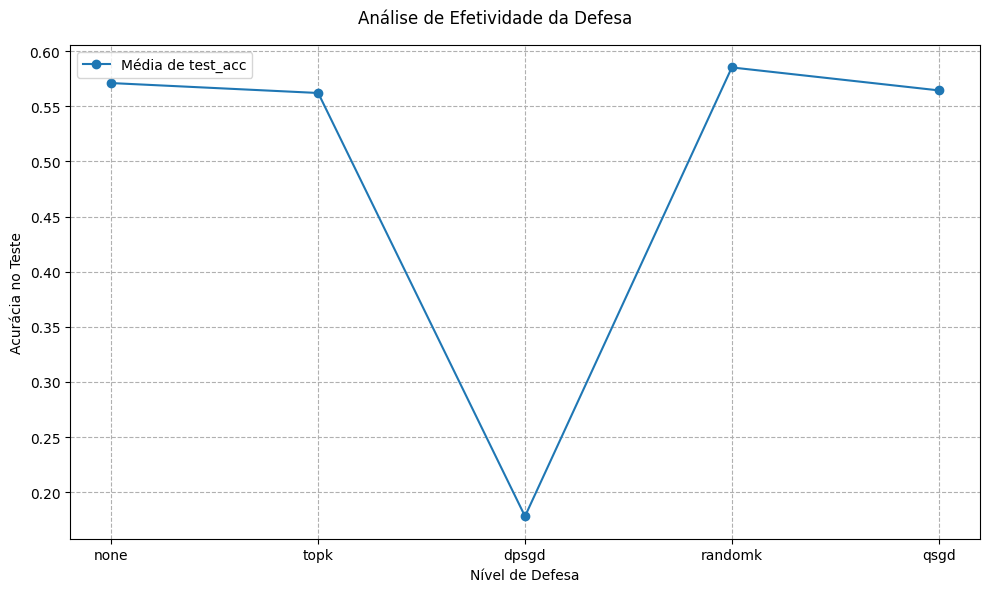

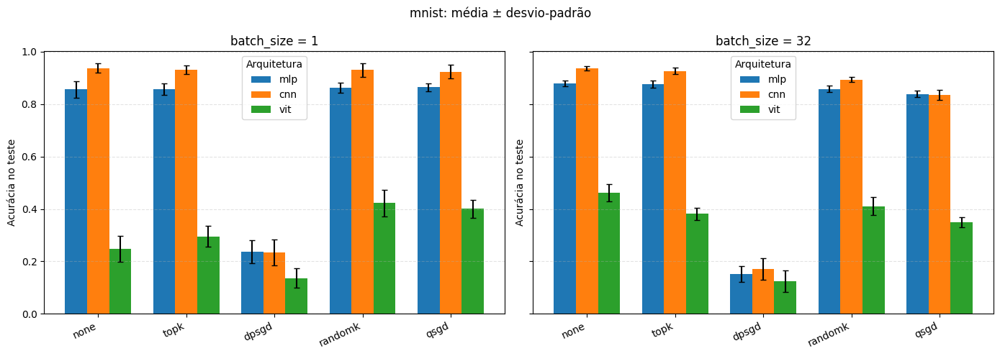

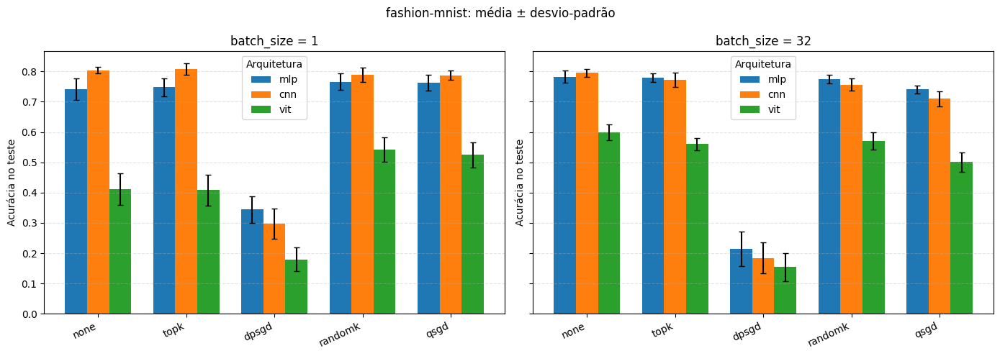

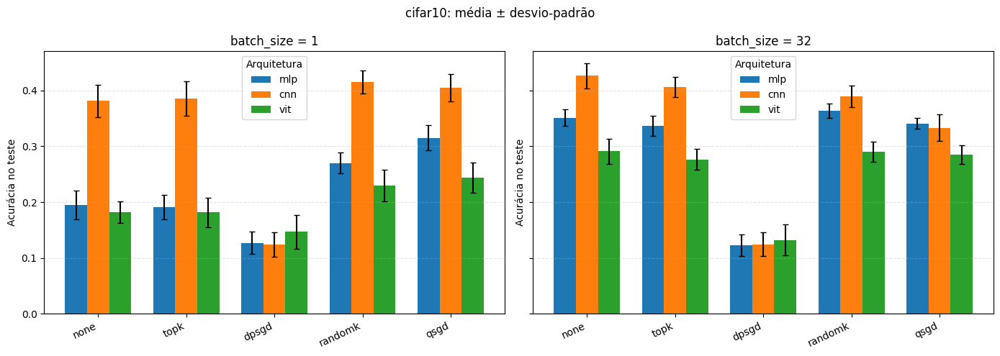


Figuras (acurácia) salvas em: ./figuras_grid/


In [9]:
# --- Célula 9: executar treino em grade (opcional) ---
# Responsável por: rodar todas as combinações (demora muito), salvar CSVs brutos
# e resumo, gerar figuras de acurácia. Respeita RUN_TRAINING_GRID.
# Pode ser rodada isoladamente depois das células 1–8.

if RUN_TRAINING_GRID:
    df_grid, df_grid_epochs = run_grid_with_repeats(N_REPEATS, DEVICE)
    print("\nAmostra (linhas brutas):")
    print(df_grid.head())
    summary = summarize_runs(df_grid)
    print("\nResumo (média e desvio-padrão por configuração):")
    print(summary.to_string())
    df_grid.to_csv("resultados_grid_privacidade_utilidade.csv", index=False)
    summary.to_csv("resultados_grid_resumo_medias.csv", index=False)
    print("\nCSV brutos: resultados_grid_privacidade_utilidade.csv")
    print("CSV resumo: resultados_grid_resumo_medias.csv")
    if SAVE_EPOCH_HISTORY and len(df_grid_epochs) > 0:
        df_grid_epochs.to_csv(EPOCH_HISTORY_CSV, index=False)
        print(f"Histórico por época: {EPOCH_HISTORY_CSV} ({len(df_grid_epochs)} linhas)")
    plot_tradeoff_curve(df_grid, metric="test_acc")
    plot_acc_by_dataset_arch(df_grid)
    print(f"\nFiguras (acurácia) salvas em: {OUTDIR}/")
else:
    print("RUN_TRAINING_GRID=False — pulando treino em grade e CSV de acurácia.")



--- Reconstruções (ataque ao gradiente, estilo TP2) ---
Recon mnist: 30 amostras -> [817, 878, 970, 1171, 1289, 1798, 2218, 2255, 2536, 3225, 3260, 3592]...
Recon fashion-mnist: 30 amostras -> [725, 818, 1051, 1195, 1384, 1972, 2284, 2308, 2312, 3214, 3240, 3666]...


/Users/nieg/Documents/nonlinear-optimization-article/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Recon cifar10: 30 amostras -> [616, 724, 1116, 1170, 1543, 1887, 2286, 2298, 2554, 3174, 3307, 3316]...
Reconstruções: mnist / mlp ...


/opt/homebrew/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


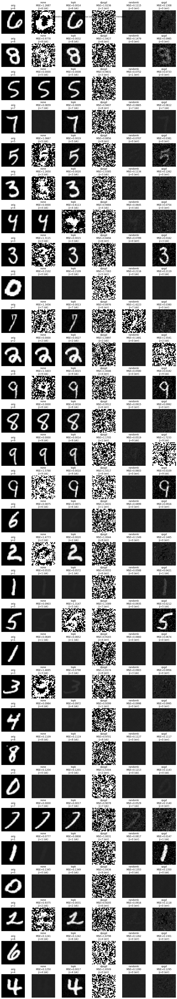

Reconstruções: mnist / cnn ...


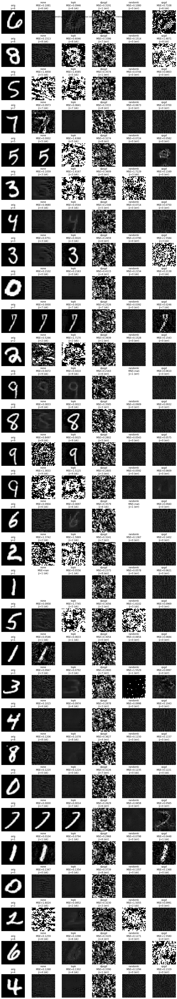

Reconstruções: mnist / vit ...


/var/folders/6k/khn05wys1sbg0cbqqxm2p6fr0000gn/T/ipykernel_10411/2270577482.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=depth)


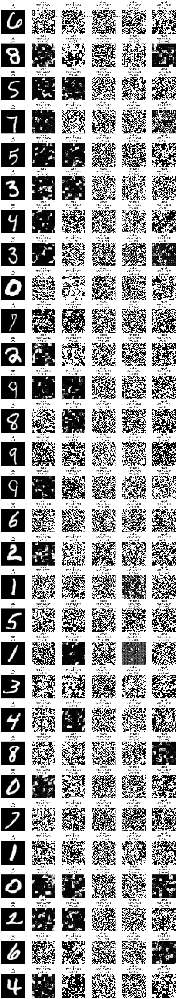

Reconstruções: fashion-mnist / mlp ...


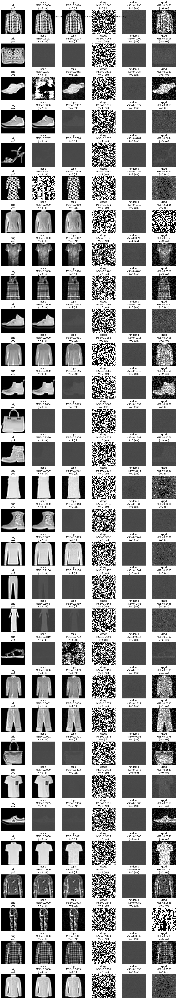

Reconstruções: fashion-mnist / cnn ...


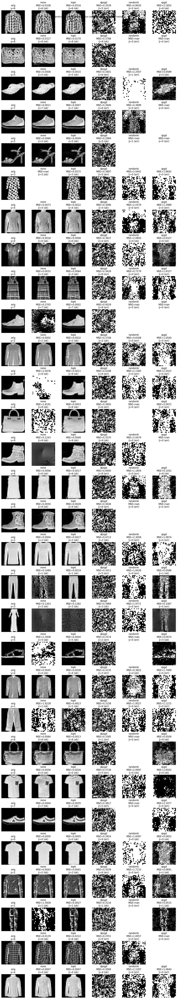

Reconstruções: fashion-mnist / vit ...


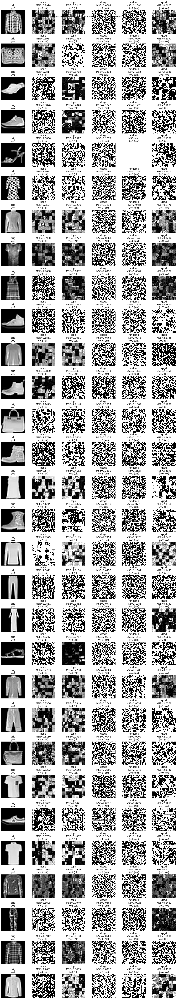

Reconstruções: cifar10 / mlp ...


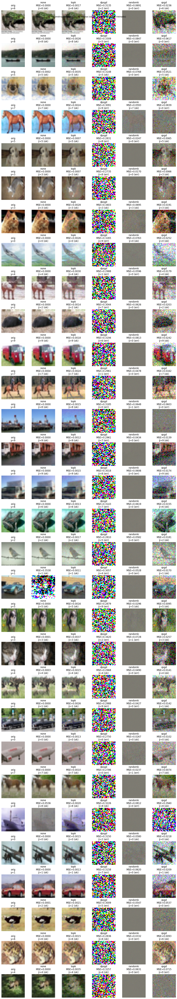

Reconstruções: cifar10 / cnn ...


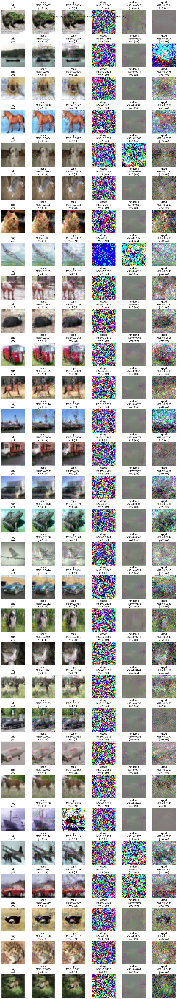

Reconstruções: cifar10 / vit ...


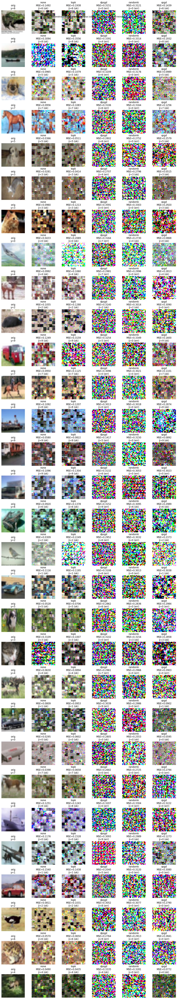

MSE (detalhe) salvo em: recon_mse_privacidade_detalhe.csv
MSE (resumo média ± dp) salvo em: recon_mse_privacidade_resumo.csv
          dataset arch  defense  mse_mean   mse_std  label_acc   n
0         cifar10  cnn    dpsgd  0.275639  0.042508   0.133333  30
1         cifar10  cnn     none  0.009212  0.004571   1.000000  30
2         cifar10  cnn     qsgd  0.052293  0.045760   0.866667  30
3         cifar10  cnn  randomk  0.086003  0.079024   0.300000  30
4         cifar10  cnn     topk  0.017527  0.046091   1.000000  30
5         cifar10  mlp    dpsgd  0.305688  0.018642   0.200000  30
6         cifar10  mlp     none  0.013608  0.064984   1.000000  30
7         cifar10  mlp     qsgd  0.035064  0.053063   0.833333  30
8         cifar10  mlp  randomk  0.055568  0.018525   0.200000  30
9         cifar10  mlp     topk  0.001922  0.000817   1.000000  30
10        cifar10  vit    dpsgd  0.297695  0.040201   0.100000  30
11        cifar10  vit     none  0.098374  0.067446   1.000000  30
12  

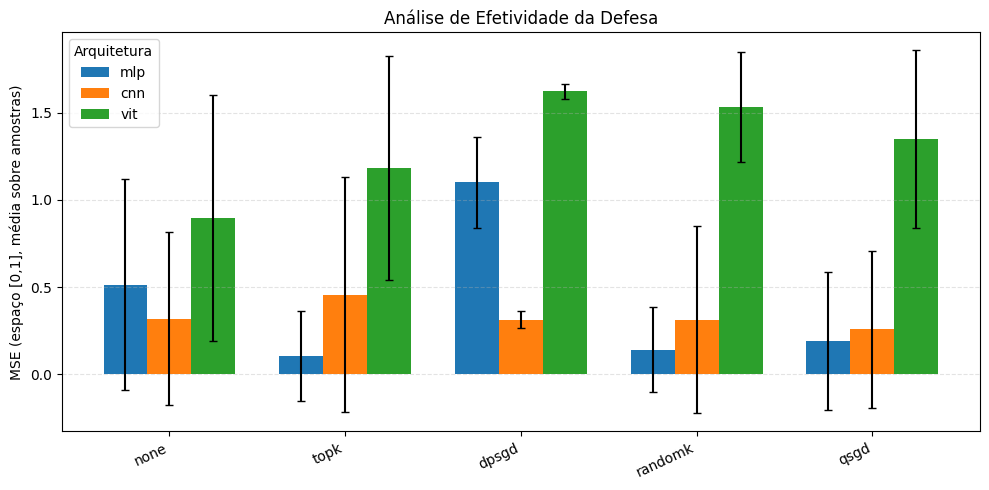

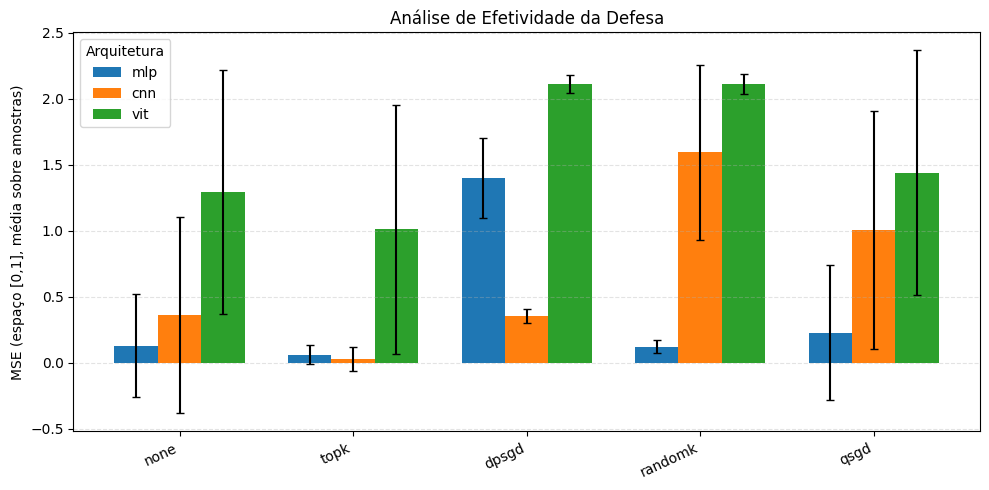

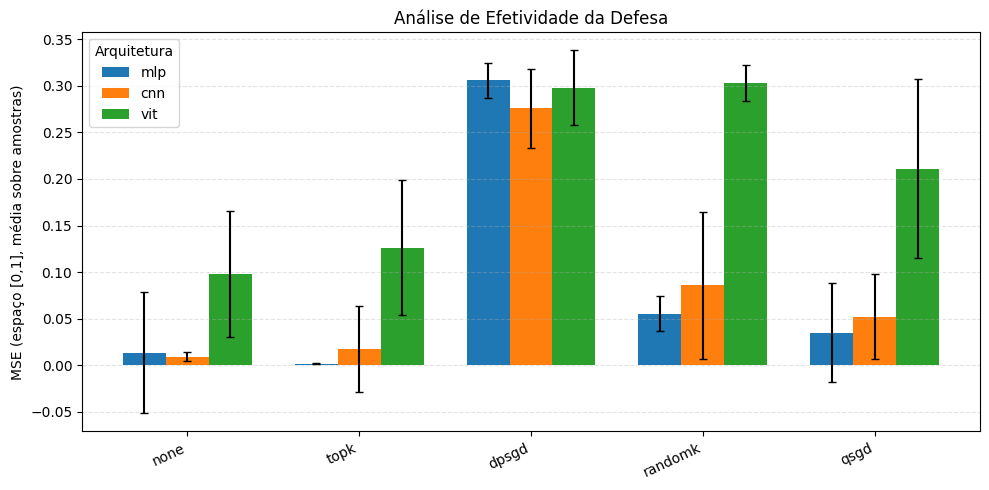

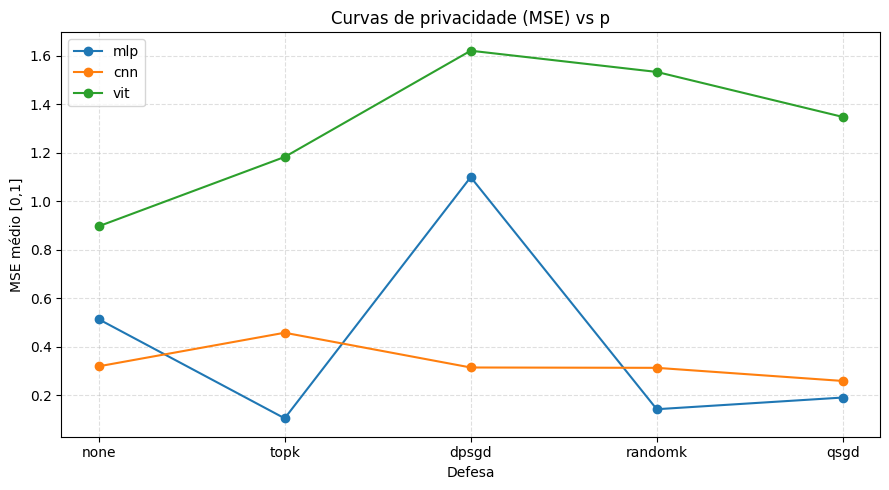

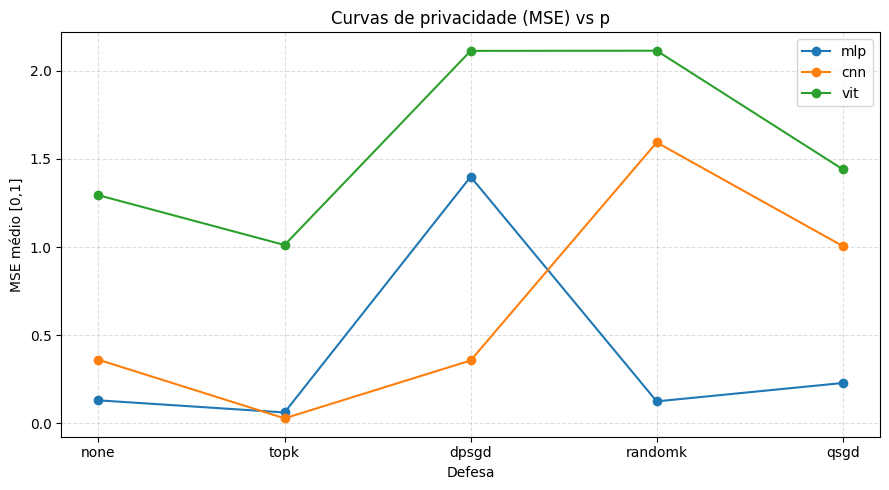

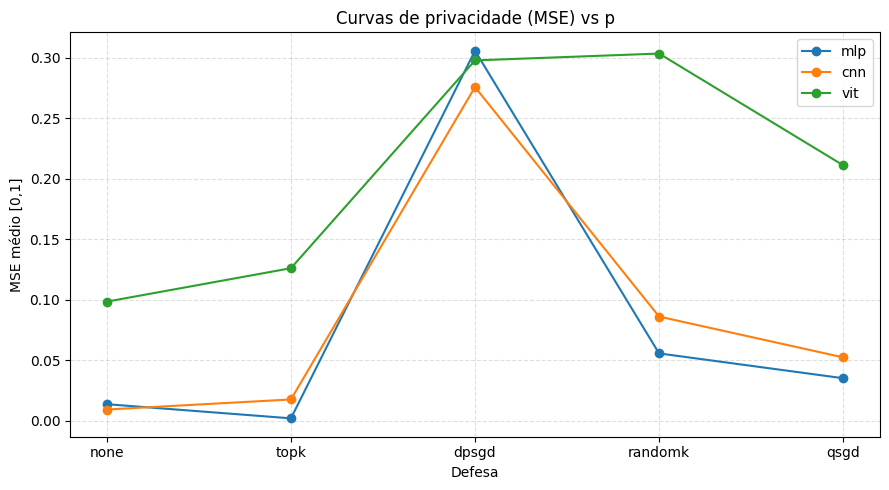

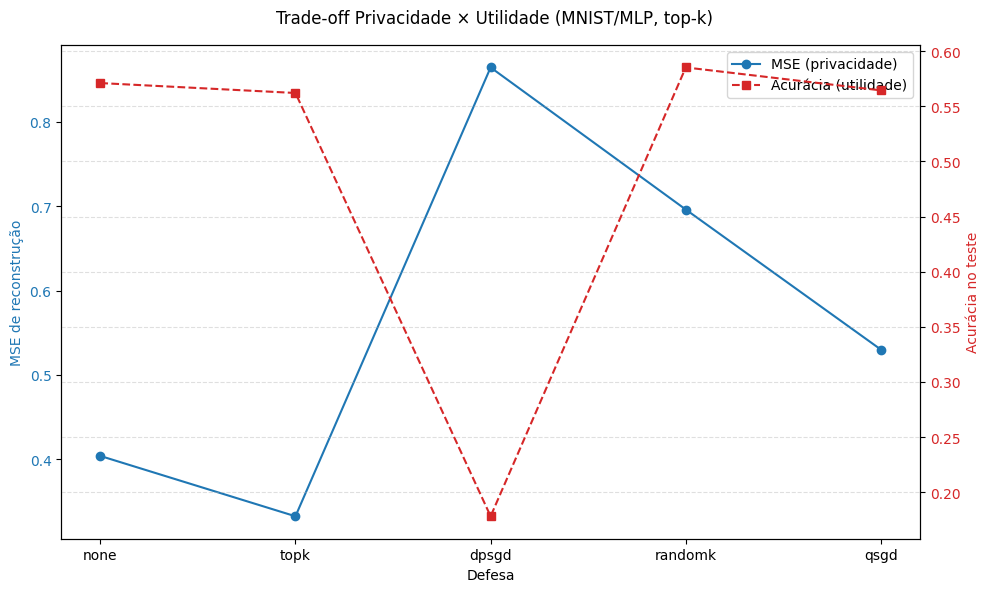

/opt/homebrew/Cellar/python@3.11/3.11.14/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


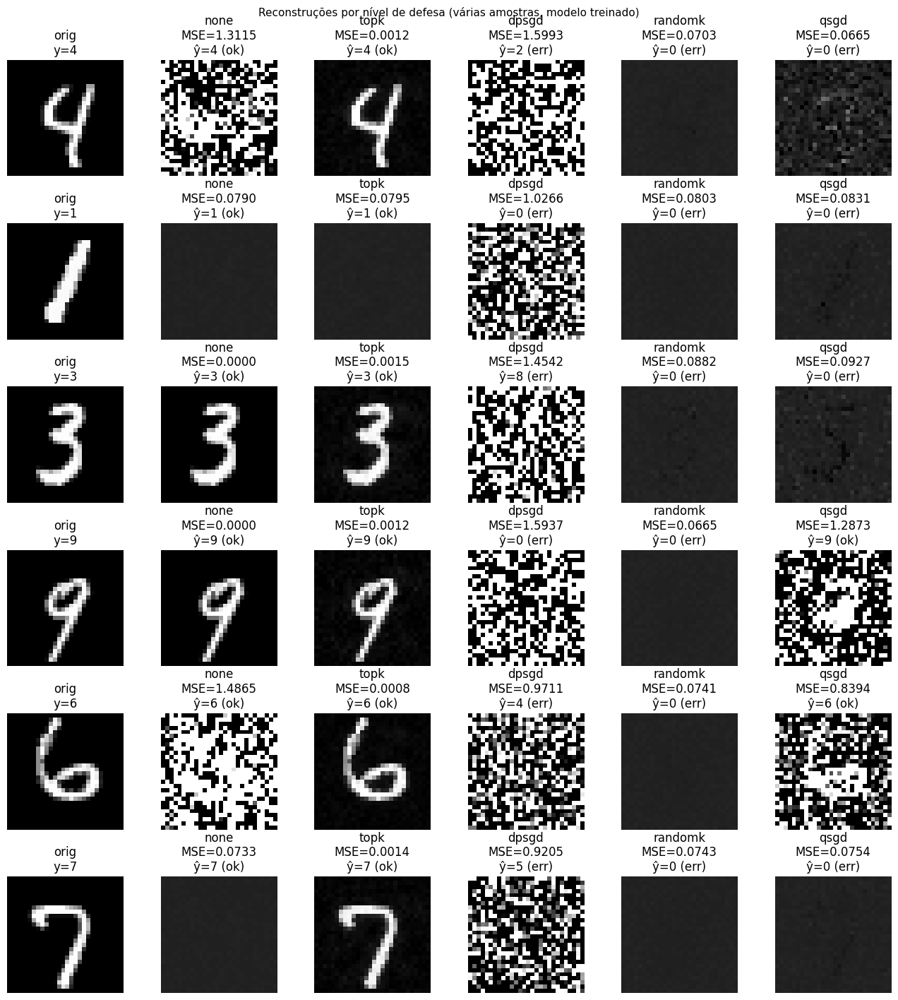

Figuras de reconstrução salvas em: ./figuras_grid/


In [11]:
# --- Célula 10: executar reconstruções e trade-off MSE×acurácia (opcional) ---
# Responsável por: figuras de reconstrução, CSVs de MSE, curvas de privacidade;
# se o treino (célula 9) já produziu `summary`, também gera trade-off global MSE×acc.
# Respeita RUN_RECONSTRUCTION_PLOTS.

if RUN_RECONSTRUCTION_PLOTS:
    print("\n--- Reconstruções (ataque ao gradiente, estilo TP2) ---")
    if df_grid is None:
        raise RuntimeError("df_grid está vazio. Rode a célula 9 nesta sessão para gerar e indexar checkpoints antes da reconstrução.")
    df_mse_recon, summary_mse_recon = run_all_reconstruction_figures(df_grid)
    if RUN_TRAINING_GRID and summary is not None:
        plot_tradeoff_mse_acc(summary_mse_recon, summary)
    q_idx = RECON_SAMPLE_INDICES if not RECON_USE_STRATIFIED else pick_recon_indices(get_raw_dataset('mnist', train=False), max(1, RECON_SAMPLES_PER_CLASS // 2), seed=RECON_SEED_BASE)[:6]
    plot_qualitative_multi('mnist', 'mlp', q_idx, df_grid)
    print(f"Figuras de reconstrução salvas em: {OUTDIR}/")
else:
    print("RUN_RECONSTRUCTION_PLOTS=False — pulando figuras de reconstrução.")
